# Imports

In [4]:
import sys, os
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score 
import matplotlib.pyplot as plt
from src.models import config
from scipy.stats import bootstrap
import seaborn as sns

# Reading in the data

In [5]:
df_drain = pd.read_csv("../reports/chestx/drain/calibration_drain.csv")
df_padchest_scanner = pd.read_csv("../reports/padchest/padchest_scanner/calibration_scanner.csv")
df_padchest_scanner_px = pd.read_csv("../reports/padchest_px/padchest_scanner_px/calibration_scanner.csv")

df_sex = pd.read_csv("../reports/chestx/sex/calibration_sex.csv")
df_padchest_sex = pd.read_csv("../reports/padchest/padchest_sex/calibration_sex.csv")
df_padchest_sex_px = pd.read_csv("../reports/padchest_px/padchest_sex_px/calibration_sex.csv")

# chestx pneumothorax

## overall

In [6]:
y_true = df_drain["y_true"]
y_prob = df_drain["y_prob"]

df_drain["y_pred"] = (df_drain["y_prob"]).astype(int)

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.8386699375391857


## drains

In [7]:
y_true = df_drain.loc[df_drain["drain"] == 1, "y_true"]
y_prob = df_drain.loc[df_drain["drain"] == 1, "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.8402015212114905


## no drains

In [8]:
y_true = df_drain.loc[df_drain["drain"] == 0, "y_true"]
y_prob = df_drain.loc[df_drain["drain"] == 0, "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.8116077073672274


## sex female

In [9]:
y_true = df_sex.loc[df_sex["sex"] == "F", "y_true"]
y_prob = df_sex.loc[df_sex["sex"] == "F", "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.8402298079602535


## sex male

In [10]:
y_true = df_sex.loc[df_sex["sex"] == "M", "y_true"]
y_prob = df_sex.loc[df_sex["sex"] == "M", "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.837117759029667


# PadChest cardiomegaly

## overall

In [11]:
y_true = df_padchest_scanner["y_true"]
y_prob = df_padchest_scanner["y_prob"]

df_padchest_scanner["y_pred"] = (df_padchest_scanner["y_prob"]).astype(int)

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.9050495971229963


## scanner PMS

In [12]:
y_true = df_padchest_scanner.loc[df_padchest_scanner["scanner"] == "PhilipsMedicalSystems", "y_true"]
y_prob = df_padchest_scanner.loc[df_padchest_scanner["scanner"] == "PhilipsMedicalSystems", "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.8933869377226639


## scanner IDC

In [13]:
y_true = df_padchest_scanner.loc[df_padchest_scanner["scanner"] == "ImagingDynamicsCompanyLtd", "y_true"]
y_prob = df_padchest_scanner.loc[df_padchest_scanner["scanner"] == "ImagingDynamicsCompanyLtd", "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.9170265997875008


## sex female

In [14]:
y_true = df_padchest_sex.loc[df_padchest_sex["sex"] == "F", "y_true"]
y_prob = df_padchest_sex.loc[df_padchest_sex["sex"] == "F", "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.9107721059704813


## sex male

In [15]:
y_true = df_padchest_sex.loc[df_padchest_sex["sex"] == "M", "y_true"]
y_prob = df_padchest_sex.loc[df_padchest_sex["sex"] == "M", "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.8973198018834405


# PadChest pneumothorax

## overall

In [16]:
y_true = df_padchest_scanner_px["y_true"]
y_prob = df_padchest_scanner_px["y_prob"]

df_padchest_scanner_px["y_pred"] = (df_padchest_scanner_px["y_prob"]).astype(int)

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.8748830419879263


## scanner PMS

In [17]:
y_true = df_padchest_scanner_px.loc[df_padchest_scanner_px["scanner"] == "PhilipsMedicalSystems", "y_true"]
y_prob = df_padchest_scanner_px.loc[df_padchest_scanner_px["scanner"] == "PhilipsMedicalSystems", "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.8009101822755992


## scanner IDC

In [18]:
y_true = df_padchest_scanner_px.loc[df_padchest_scanner_px["scanner"] == "ImagingDynamicsCompanyLtd", "y_true"]
y_prob = df_padchest_scanner_px.loc[df_padchest_scanner_px["scanner"] == "ImagingDynamicsCompanyLtd", "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.8519058909356192


## sex female

In [19]:
y_true = df_padchest_sex_px.loc[df_padchest_sex_px["sex"] == "F", "y_true"]
y_prob = df_padchest_sex_px.loc[df_padchest_sex_px["sex"] == "F", "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.8949241088704477


## sex male

In [20]:
y_true = df_padchest_sex_px.loc[df_padchest_sex_px["sex"] == "M", "y_true"]
y_prob = df_padchest_sex_px.loc[df_padchest_sex_px["sex"] == "M", "y_prob"]

auroc = roc_auc_score(y_true=y_true, y_score=y_prob)
print(f"auroc: {auroc}")

auroc: 0.8562148532807954


# __________________________________________________________________

# Getting all AUROC
to be able to make confidence intervals using bootstrapping

In [21]:
def auroc_stat(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)

def bootstrap_auroc(df, subgroup_col=None, subgroup_value=None):
    if subgroup_col is not None:
        df = df[df[subgroup_col] == subgroup_value].reset_index(drop=True)

    y_true = df["y_true"].values
    y_prob = df["y_prob"].values

    res = bootstrap((y_true, y_prob), statistic=auroc_stat, n_resamples=config.N_BOOT, confidence_level=0.95,
        method="percentile", paired=True, random_state=np.random.default_rng(config.BOOT_SEED))

    mean = roc_auc_score(y_true, y_prob)
    return mean, res.confidence_interval.low, res.confidence_interval.high

In [22]:
evaluation = [("ChestX pneumothorax", "global", df_drain, None),
    ("ChestX pneumothorax", "drain", df_drain, df_drain["drain"] == 1),
    ("ChestX pneumothorax", "no drain", df_drain, df_drain["drain"] == 0),
    ("ChestX pneumothorax", "female", df_sex, df_sex["sex"] == "F"),
    ("ChestX pneumothorax", "male", df_sex, df_sex["sex"] == "M"),

    ("PadChest cardiomegaly", "global", df_padchest_scanner, None),
    ("PadChest cardiomegaly", "PMS", df_padchest_scanner, df_padchest_scanner["scanner"] == "PhilipsMedicalSystems"),
    ("PadChest cardiomegaly", "IDC", df_padchest_scanner, df_padchest_scanner["scanner"] == "ImagingDynamicsCompanyLtd"),
    ("PadChest cardiomegaly", "female", df_padchest_sex, df_padchest_sex["sex"] == "F"),
    ("PadChest cardiomegaly", "male", df_padchest_sex, df_padchest_sex["sex"] == "M"),

    ("PadChest pneumothorax", "global",df_padchest_scanner_px, None),
    ("PadChest pneumothorax", "PMS", df_padchest_scanner_px, df_padchest_scanner_px["scanner"] == "PhilipsMedicalSystems"),
    ("PadChest pneumothorax", "IDC", df_padchest_scanner_px, df_padchest_scanner_px["scanner"] == "ImagingDynamicsCompanyLtd"),
    ("PadChest pneumothorax", "female", df_padchest_sex_px, df_padchest_sex_px["sex"] == "F"),
    ("PadChest pneumothorax", "male", df_padchest_sex_px, df_padchest_sex_px["sex"] == "M")]

rows = []
for dataset, subgroup, df, mask in evaluation:
    sub_df = df if mask is None else df[mask]
    mean, lo, hi = bootstrap_auroc(sub_df)
    rows.append({"dataset": dataset, "subgroup": subgroup, "n": len(sub_df), "value": mean, "ci_low": lo, "ci_high": hi})

result = pd.DataFrame(rows)
result

,dataset,subgroup,n,value,ci_low,ci_high
0,ChestX pneumothorax,global,25596,0.838670,0.831287,0.845732
1,ChestX pneumothorax,drain,12186,0.840202,0.830883,0.849513
2,ChestX pneumothorax,no drain,13410,0.811608,0.798553,0.825499
3,ChestX pneumothorax,female,10714,0.840230,0.829026,0.850480
4,ChestX pneumothorax,male,14882,0.837118,0.826608,0.847397
5,PadChest cardiomegaly,global,21770,0.905050,0.898644,0.911317
6,PadChest cardiomegaly,PMS,10800,0.893387,0.883918,0.902787
7,PadChest cardiomegaly,IDC,10970,0.917027,0.908534,0.925160
8,PadChest cardiomegaly,female,10760,0.910772,0.902982,0.918932
9,PadChest cardiomegaly,male,11005,0.897320,0.886930,0.908277


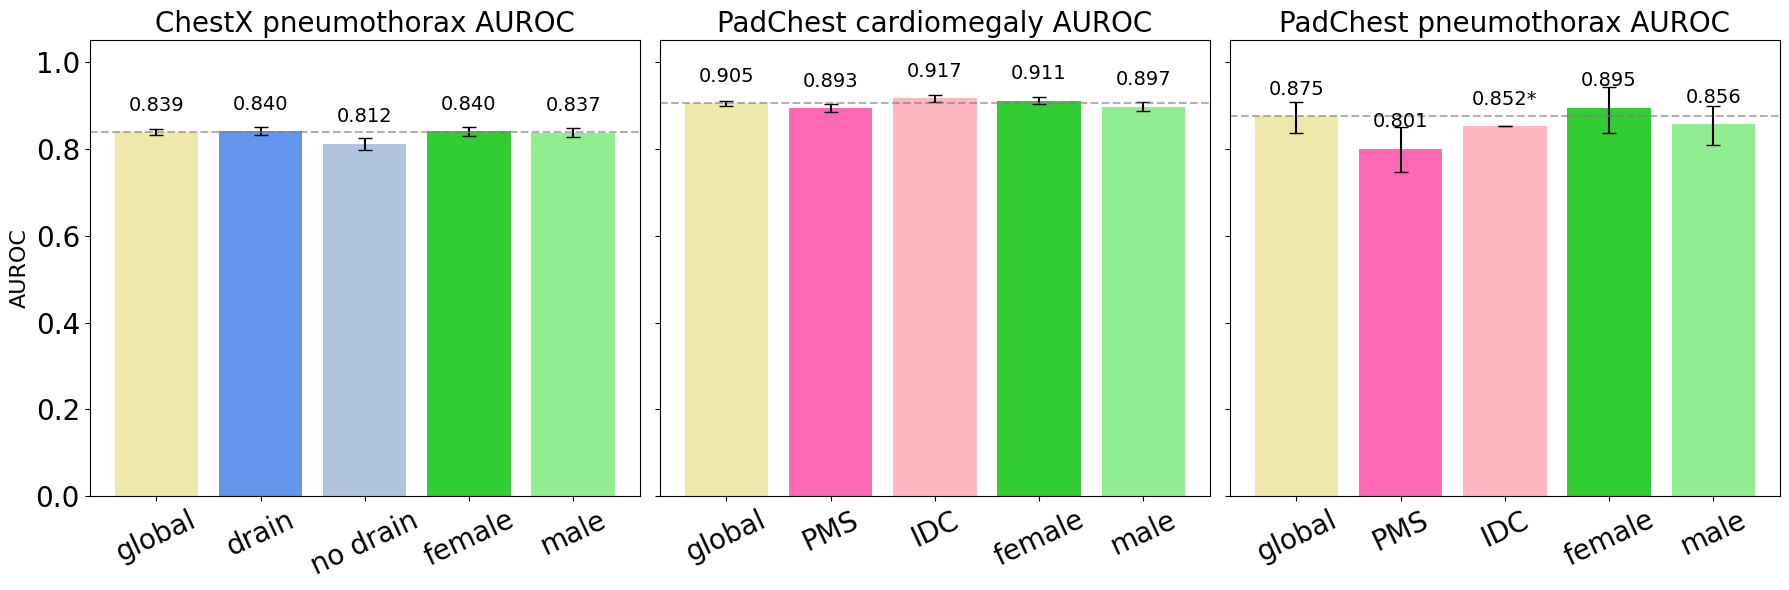

In [23]:
def generate_barplot_subgroups(df):
    dataset_order = ["ChestX pneumothorax", "PadChest cardiomegaly", "PadChest pneumothorax"]
    subgroup_order = ["global", "drain", "no drain", "PMS", "IDC", "female", "male"]

    color_map = {"global": "palegoldenrod", "drain": "cornflowerblue", "no drain": "lightsteelblue",
                 "PMS": "hotpink", "IDC": "lightpink", "female": "limegreen", "male": "lightgreen"}

    df["dataset"] = pd.Categorical(df["dataset"], dataset_order)
    df["subgroup"] = pd.Categorical(df["subgroup"], subgroup_order)
    df = df.sort_values(["dataset", "subgroup"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    for ax, dataset in zip(axes, dataset_order):
        sub = df[df["dataset"] == dataset]
        present = [g for g in subgroup_order if g in set(sub["subgroup"].dropna().astype(str).unique())]
        values = [sub.loc[sub["subgroup"] == g, "value"].iloc[0] for g in present]
        ci_lows = [sub.loc[sub["subgroup"] == g, "ci_low"].iloc[0] for g in present]
        ci_highs = [sub.loc[sub["subgroup"] == g, "ci_high"].iloc[0] for g in present]
        colors = [color_map[g] for g in present]

        # nans for the case of padchest pnuemothorax IDC, which has very few positive
        err_low = [v - lo if not np.isnan(lo) else 0 for v, lo in zip(values, ci_lows)]
        err_high = [hi - v if not np.isnan(hi) else 0 for v, hi in zip(values, ci_highs)]

        ax.bar(present, values, color=colors, yerr=[err_low, err_high], capsize=5)

        for x, v, lo in zip(present, values, ci_lows):
            label = f"{v:.3f}" + ("*" if np.isnan(lo) else "")
            ax.text(x, v + 0.04, label, ha="center", va="bottom", fontsize=14)

        if "global" in present:
            ax.axhline(y=values[present.index("global")], color="gray", linestyle="--", alpha=0.6)

        ax.set_title(f"{dataset} AUROC", fontsize=20)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', labelsize=20, rotation=25)
        ax.tick_params(axis='y', labelsize=20)

    axes[0].set_ylabel("AUROC", fontsize=16)
    plt.tight_layout()
    out_path = f"../{config.FIGS}/auroc_ci.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

generate_barplot_subgroups(result)